In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
# Step 1: Load Wine dataset

wine = load_wine()

X = wine.data
y = wine.target

feature_names = wine.feature_names
target_names = wine.target_names

print('Original shape:', X.shape)
print('Classes:', target_names)


Original shape: (178, 13)
Classes: ['class_0' 'class_1' 'class_2']


In [3]:
# Step 2: Standardize features

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [4]:
# Step 3: PCA - 2 components

pca_2d = PCA(n_components=2)

X_pca_2d = pca_2d.fit_transform(X_scaled)

print(
    'Explained variance ratio:',
    pca_2d.explained_variance_ratio_
)

print(
    'Total variance captured:',
    sum(pca_2d.explained_variance_ratio_) * 100,
    '%'
)

Explained variance ratio: [0.36198848 0.1920749 ]
Total variance captured: 55.40633835693526 %


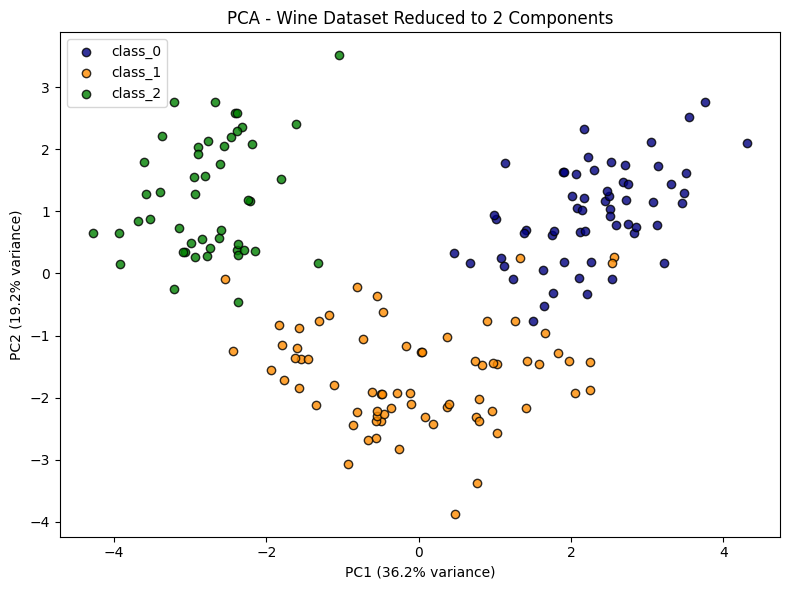

In [5]:
# Step 4: 2D visualization

plt.figure(figsize=(8, 6))

colors = ['navy', 'darkorange', 'green']

for i, target_name in enumerate(target_names):

    plt.scatter(
        X_pca_2d[y == i, 0],
        X_pca_2d[y == i, 1],
        color=colors[i],
        label=target_name,
        alpha=0.8,
        edgecolor='k'
    )

plt.xlabel(
    f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)'
)

plt.ylabel(
    f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)'
)

plt.title(
    'PCA - Wine Dataset Reduced to 2 Components'
)

plt.legend()
plt.tight_layout()
plt.show()

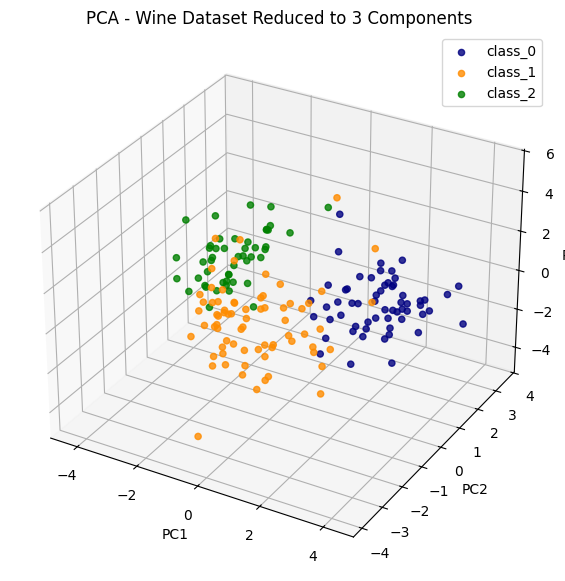

In [6]:
# Step 5: PCA - 3 components

pca_3d = PCA(n_components=3)

X_pca_3d = pca_3d.fit_transform(X_scaled)

fig = plt.figure(figsize=(9, 7))

ax = fig.add_subplot(
    111,
    projection='3d'
)

for i, target_name in enumerate(target_names):

    ax.scatter(
        X_pca_3d[y == i, 0],
        X_pca_3d[y == i, 1],
        X_pca_3d[y == i, 2],
        color=colors[i],
        label=target_name,
        alpha=0.8
    )

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')

ax.set_title(
    'PCA - Wine Dataset Reduced to 3 Components'
)

ax.legend()

plt.show()

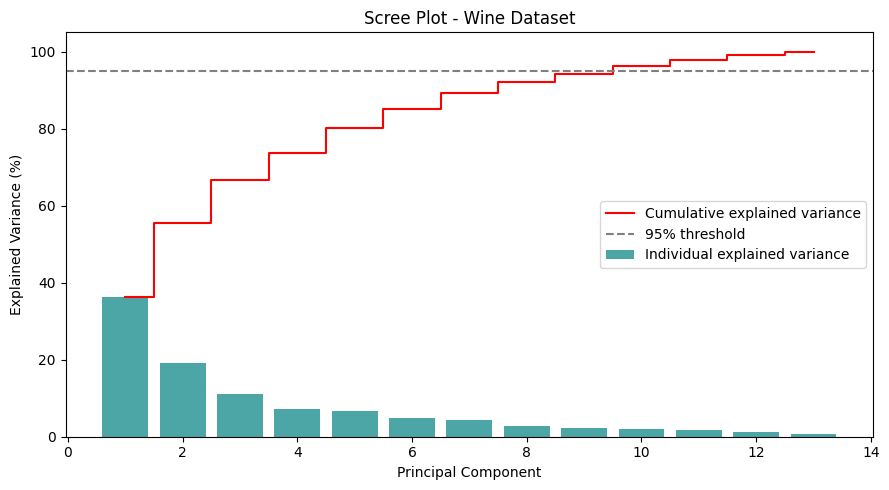

In [7]:
# Step 6: Scree plot

pca_full = PCA(n_components=None)

pca_full.fit(X_scaled)

explained_var = (
    pca_full.explained_variance_ratio_
)

cumulative_var = np.cumsum(
    explained_var
)

plt.figure(figsize=(9, 5))

plt.bar(
    range(1, len(explained_var) + 1),
    explained_var * 100,
    alpha=0.7,
    color='teal',
    label='Individual explained variance'
)

plt.step(
    range(1, len(cumulative_var) + 1),
    cumulative_var * 100,
    where='mid',
    color='red',
    label='Cumulative explained variance'
)

plt.axhline(
    y=95,
    color='gray',
    linestyle='--',
    label='95% threshold'
)

plt.xlabel('Principal Component')
plt.ylabel('Explained Variance (%)')

plt.title(
    'Scree Plot - Wine Dataset'
)

plt.legend()
plt.tight_layout()
plt.show()

In [8]:
# Step 7: Components for 95% variance

n_components_95 = (
    np.argmax(cumulative_var >= 0.95) + 1
)

print(
    f'Number of components needed to retain '
    f'95% variance: {n_components_95}'
)

Number of components needed to retain 95% variance: 10
